# AntMaze-Medium: Algorithm Comparison Plots

Comparison of 9 imitation learning algorithms (1 expert + 4 causal + 4 naive) evaluated on 1000 episodes each.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "figure.dpi": 150,
})

PLOTS_DIR = '/home/et2842/causal/causalrl/examples/experiments/plots/antmaze-medium'

In [2]:
# --- Data extracted from out_test_*.ipynb notebooks (1000 eval episodes each) ---

algorithms = [
    'Expert',
    'Causal BC', 'Causal GAIL', 'Causal SQIL', 'Causal IQLearn',
    'Naive BC',  'Naive GAIL',  'Naive SQIL',  'Naive IQLearn',
]

# E[Y] and Std[Y]
mean_rewards = np.array([
    -103.9545,   # Expert
    -154.0120,   # Causal BC
    -186.0156,   # Causal GAIL
    -135.9300,   # Causal SQIL
    -142.4897,   # Causal IQLearn
    -375.3281,   # Naive BC
    -364.8926,   # Naive GAIL
    -370.6745,   # Naive SQIL
    -372.5462,   # Naive IQLearn
])

std_rewards = np.array([
    87.5173,     # Expert
    113.8964,    # Causal BC
    122.9877,    # Causal GAIL
    110.0002,    # Causal SQIL
    111.5273,    # Causal IQLearn
    119.1750,    # Naive BC
    112.2076,    # Naive GAIL
    119.0691,    # Naive SQIL
    120.8261,    # Naive IQLearn
])

# Success rates and standard errors
success_rates = np.array([
    87.60,  # Expert
    66.00,  # Causal BC
    57.20,  # Causal GAIL
    76.70,  # Causal SQIL
    74.00,  # Causal IQLearn
    0.00,   # Naive BC
    0.00,   # Naive GAIL
    0.00,   # Naive SQIL
    0.00,   # Naive IQLearn
])

success_se = np.array([
    1.04,  # Expert
    1.50,  # Causal BC
    1.56,  # Causal GAIL
    1.34,  # Causal SQIL
    1.39,  # Causal IQLearn
    0.00,  # Naive BC
    0.00,  # Naive GAIL
    0.00,  # Naive SQIL
    0.00,  # Naive IQLearn
])

# Successful episode lengths (mean, std) — only for algorithms with successes
# Naive algorithms have 0% success, so no episode length data
succ_len_mean = np.array([
    301.34,  # Expert
    357.84,  # Causal BC
    390.39,  # Causal GAIL
    330.74,  # Causal SQIL
    351.47,  # Causal IQLearn
    np.nan,  # Naive BC
    np.nan,  # Naive GAIL
    np.nan,  # Naive SQIL
    np.nan,  # Naive IQLearn
])

succ_len_std = np.array([
    57.08,   # Expert
    112.12,  # Causal BC
    119.09,  # Causal GAIL
    91.18,   # Causal SQIL
    86.38,   # Causal IQLearn
    np.nan,  # Naive BC
    np.nan,  # Naive GAIL
    np.nan,  # Naive SQIL
    np.nan,  # Naive IQLearn
])

# Blue color palette — dark blues for Expert/Causal, lighter blues for Naive
colors = [
    '#082B47',  # Expert — darkest navy
    '#0A5E8C',  # Causal BC
    '#1976B0',  # Causal GAIL
    '#2B8CC4',  # Causal SQIL
    '#4BA3D8',  # Causal IQLearn
    '#7BBDE5',  # Naive BC
    '#9ED0EE',  # Naive GAIL
    '#BDE0F5',  # Naive SQIL
    '#D6ECF9',  # Naive IQLearn
]

x = np.arange(len(algorithms))

## 1. E[Y] — Mean Episode Return

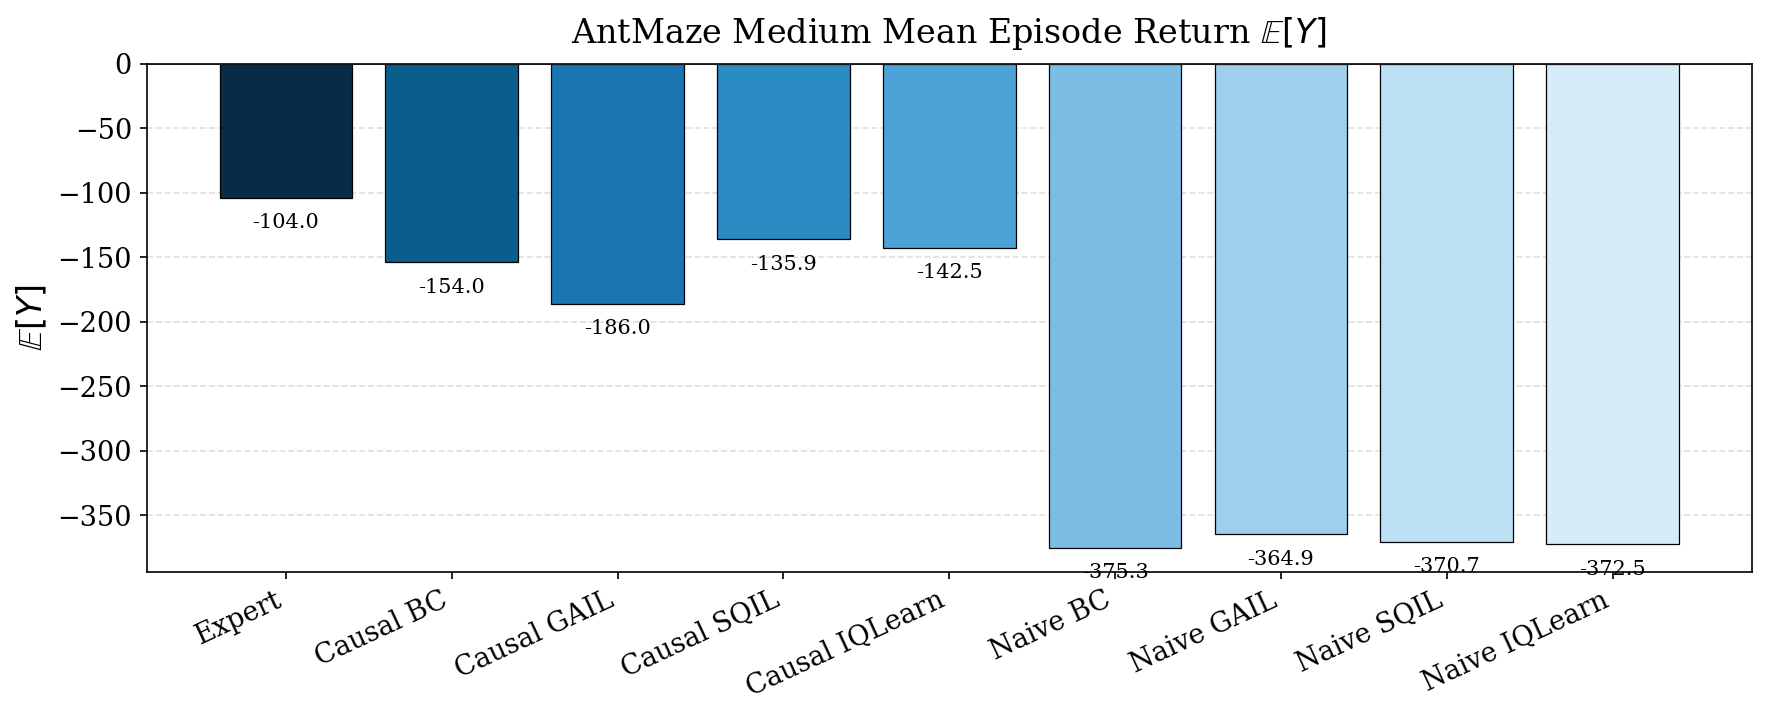

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(x, mean_rewards, color=colors, edgecolor='black', linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(algorithms, rotation=25, ha='right')
ax.set_ylabel('$\\mathbb{E}[Y]$')
ax.set_title('AntMaze Medium Mean Episode Return $\\mathbb{E}[Y]$', pad=10)
ax.axhline(y=0, color='grey', linewidth=0.5)
for bar, v in zip(bars, mean_rewards):
    ax.text(bar.get_x() + bar.get_width()/2, v - 12, f'{v:.1f}',
            ha='center', va='top', fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antmed_mean_return.pdf', dpi=300, bbox_inches='tight')
plt.show()

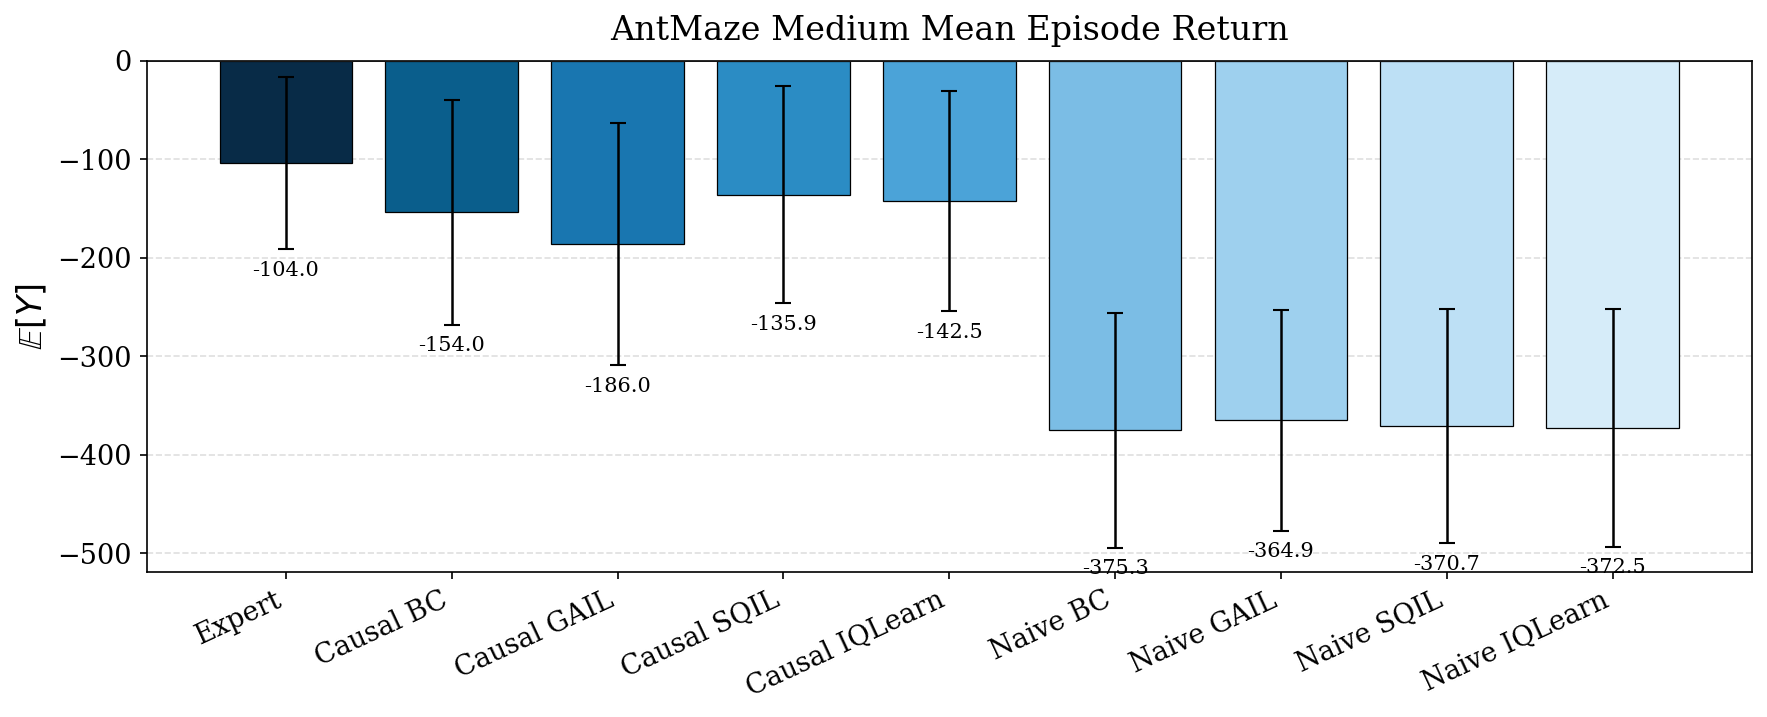

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(x, mean_rewards, yerr=std_rewards, capsize=4,
              color=colors, edgecolor='black', linewidth=0.6,
              error_kw={'linewidth': 1.2, 'capthick': 1.0})
ax.set_xticks(x)
ax.set_xticklabels(algorithms, rotation=25, ha='right')
ax.set_ylabel('$\\mathbb{E}[Y]$')
ax.set_title('AntMaze Medium Mean Episode Return', pad=10)
ax.axhline(y=0, color='grey', linewidth=0.5)
for bar, m, s in zip(bars, mean_rewards, std_rewards):
    ax.text(bar.get_x() + bar.get_width()/2, m - s - 12, f'{m:.1f}',
            ha='center', va='top', fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antmed_mean_return_with_std.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 2. Normalized E[Y]  (relative to worst algorithm)

In [5]:
# Normalize: shift so the worst algorithm score becomes 0.
# Every other bar shows how much better it is than the worst one.
worst_return = mean_rewards.min()

norm_mean = mean_rewards - worst_return
norm_std  = std_rewards  # absolute spread unchanged by shift

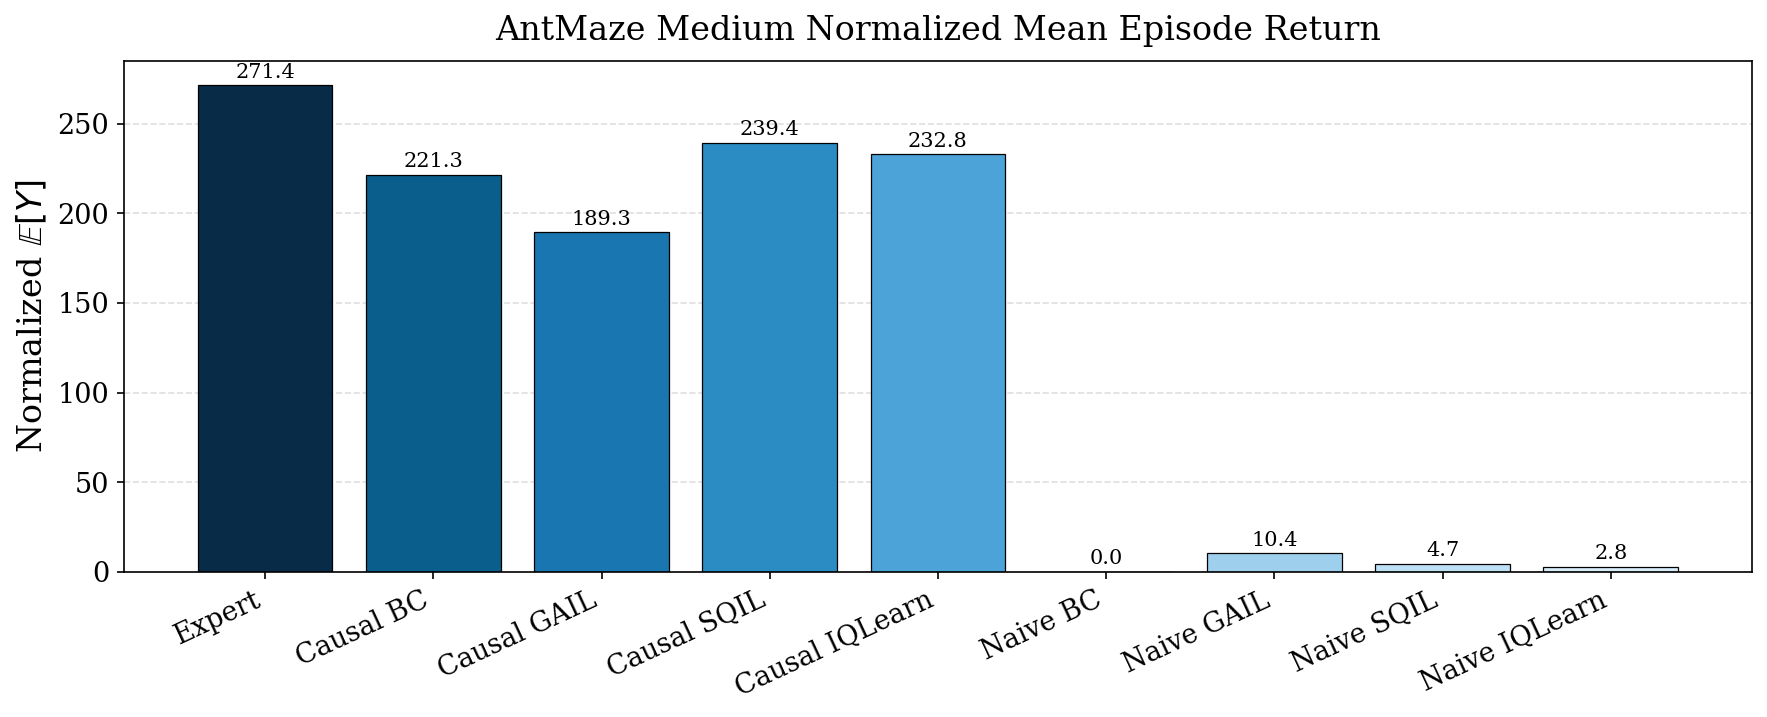

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(x, norm_mean, color=colors, edgecolor='black', linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(algorithms, rotation=25, ha='right')
ax.set_ylabel('Normalized $\\mathbb{E}[Y]$')
ax.set_title('AntMaze Medium Normalized Mean Episode Return', pad=10)
for bar, v in zip(bars, norm_mean):
    ax.text(bar.get_x() + bar.get_width()/2, v + 2, f'{v:.1f}',
            ha='center', va='bottom', fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antmed_normalized_return.pdf', dpi=300, bbox_inches='tight')
plt.show()

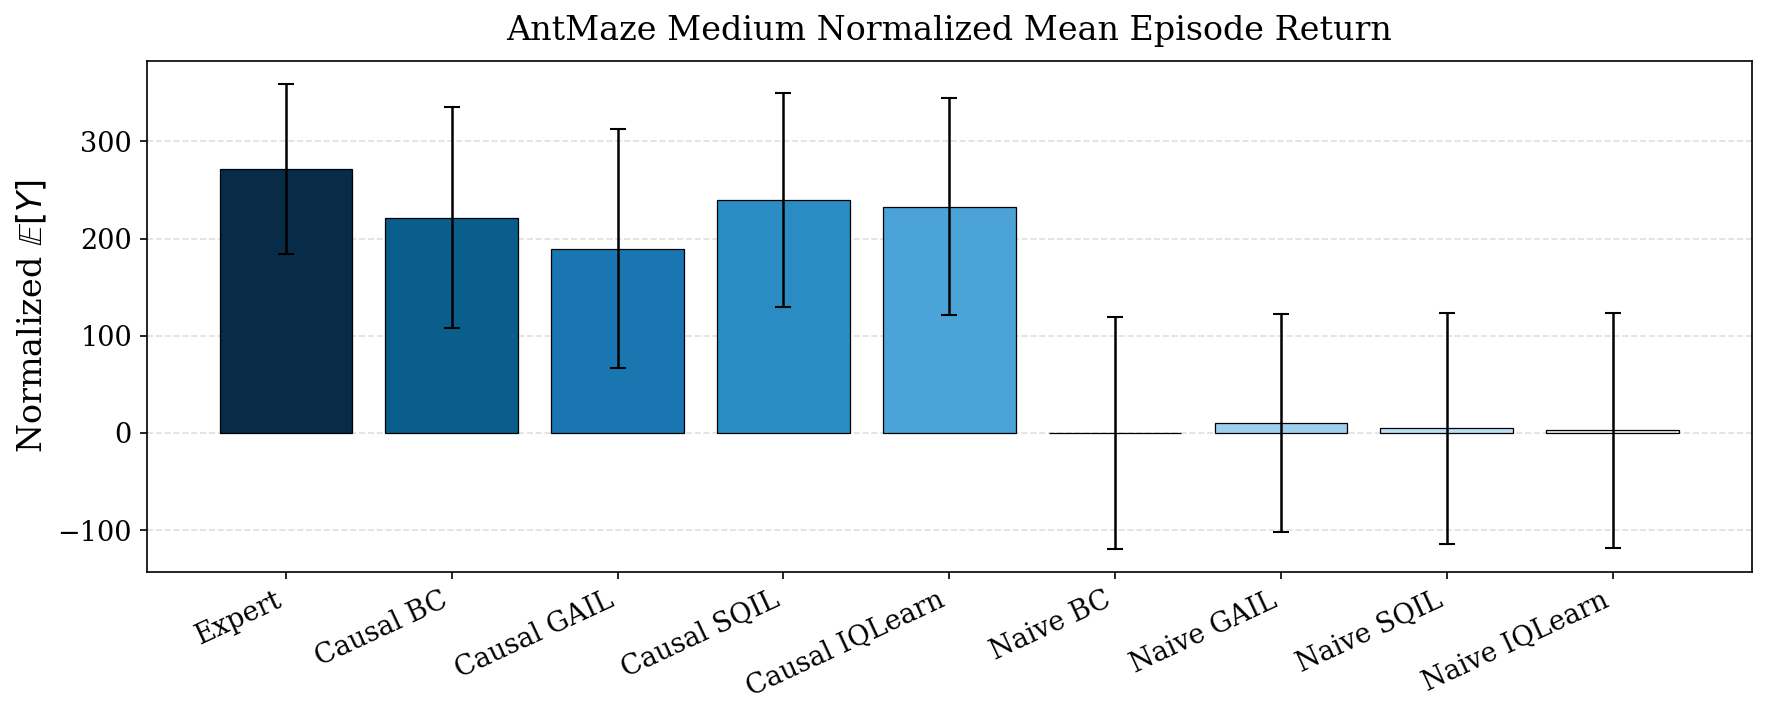

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(x, norm_mean, yerr=norm_std, capsize=4,
              color=colors, edgecolor='black', linewidth=0.6,
              error_kw={'linewidth': 1.2, 'capthick': 1.0})
ax.set_xticks(x)
ax.set_xticklabels(algorithms, rotation=25, ha='right')
ax.set_ylabel('Normalized $\\mathbb{E}[Y]$')
ax.set_title('AntMaze Medium Normalized Mean Episode Return', pad=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antmed_normalized_return_with_std.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 3. Success Rate (% of Solved Mazes)

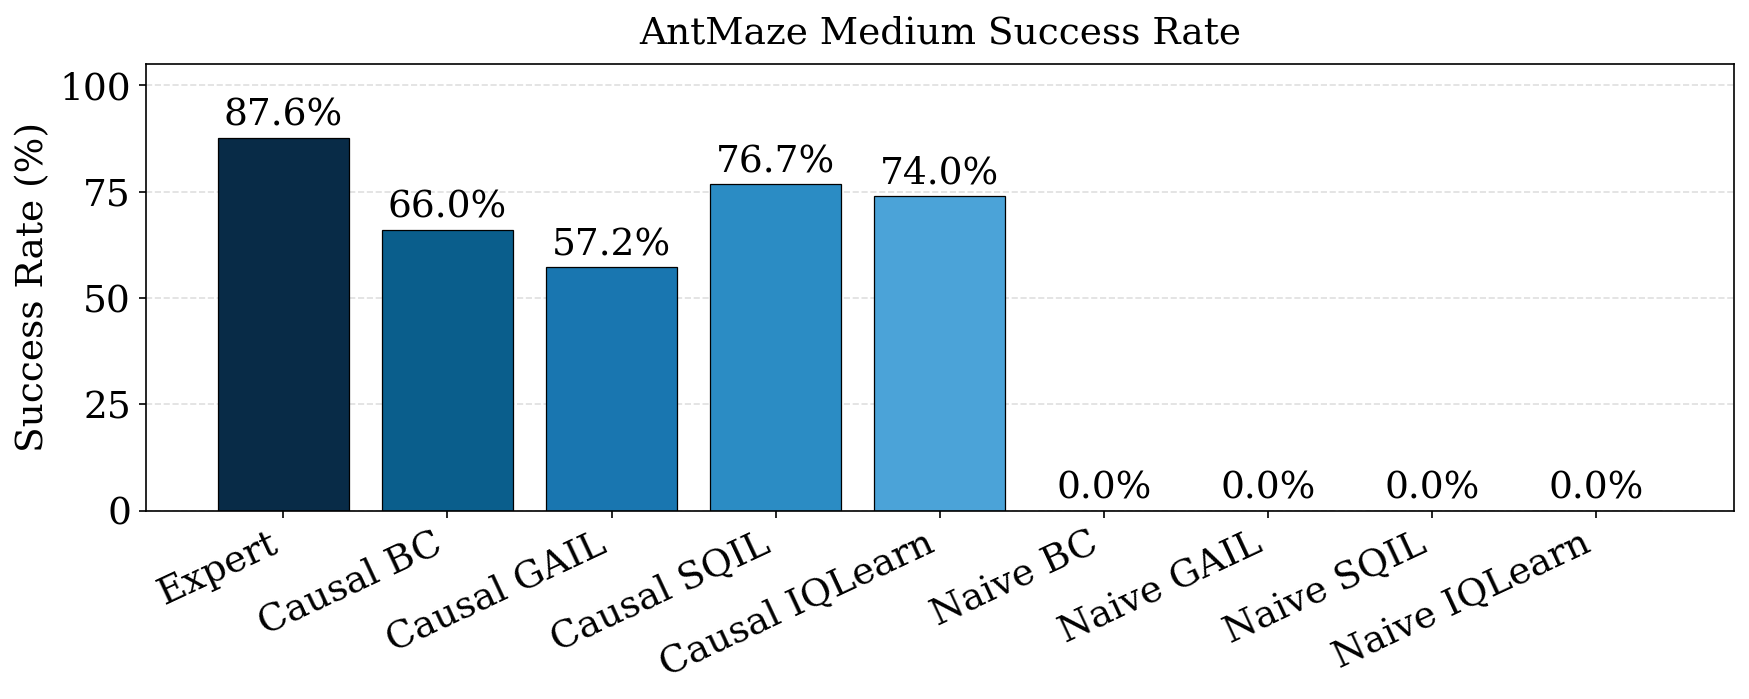

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(x, success_rates, color=colors, edgecolor='black', linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(algorithms, rotation=25, ha='right')
ax.set_ylabel('Success Rate (%)')
ax.set_title('AntMaze Medium Success Rate', pad=10)
for bar, v in zip(bars, success_rates):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1.0, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=18)
ax.set_ylim(0, 105)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antmed_success_rate.pdf', dpi=300, bbox_inches='tight')
plt.show()

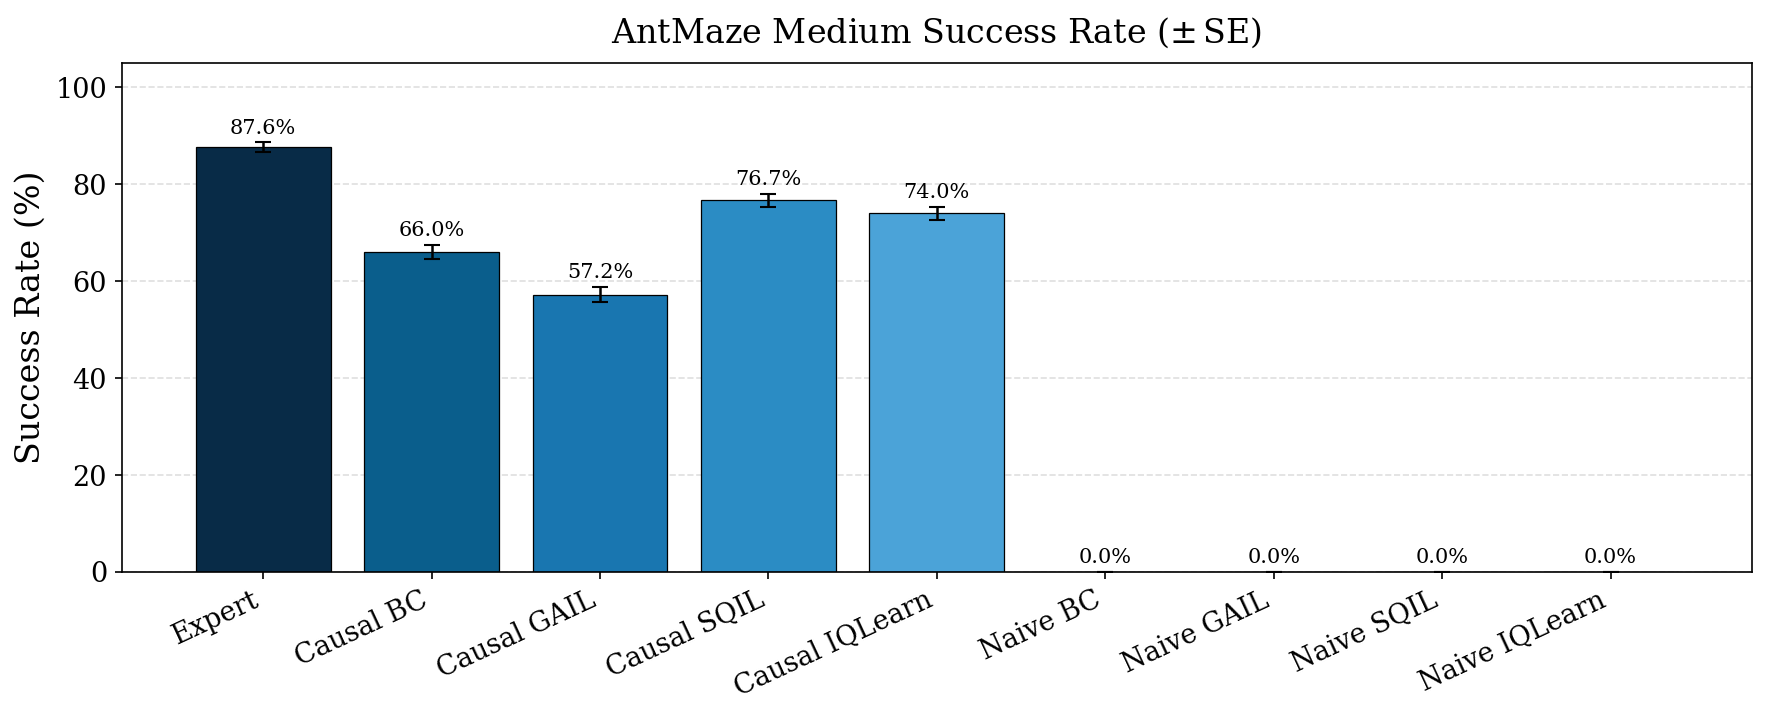

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(x, success_rates, yerr=success_se, capsize=4,
              color=colors, edgecolor='black', linewidth=0.6,
              error_kw={'linewidth': 1.2, 'capthick': 1.0})
ax.set_xticks(x)
ax.set_xticklabels(algorithms, rotation=25, ha='right')
ax.set_ylabel('Success Rate (%)')
ax.set_title('AntMaze Medium Success Rate ($\\pm\\,$SE)', pad=10)
for bar, v, se in zip(bars, success_rates, success_se):
    ax.text(bar.get_x() + bar.get_width()/2, v + se + 1.0, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, 105)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antmed_success_rate_with_se.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 4. Successful Episode Lengths

Only algorithms with at least one successful episode are shown. Naive BC, Naive GAIL, Naive SQIL, and Naive IQLearn all have 0% success rate.

In [10]:
# Filter to algorithms with successful episodes
mask = ~np.isnan(succ_len_mean)
succ_algos   = [a for a, m in zip(algorithms, mask) if m]
succ_means   = succ_len_mean[mask]
succ_stds    = succ_len_std[mask]
succ_colors  = [c for c, m in zip(colors, mask) if m]
x_succ = np.arange(len(succ_algos))

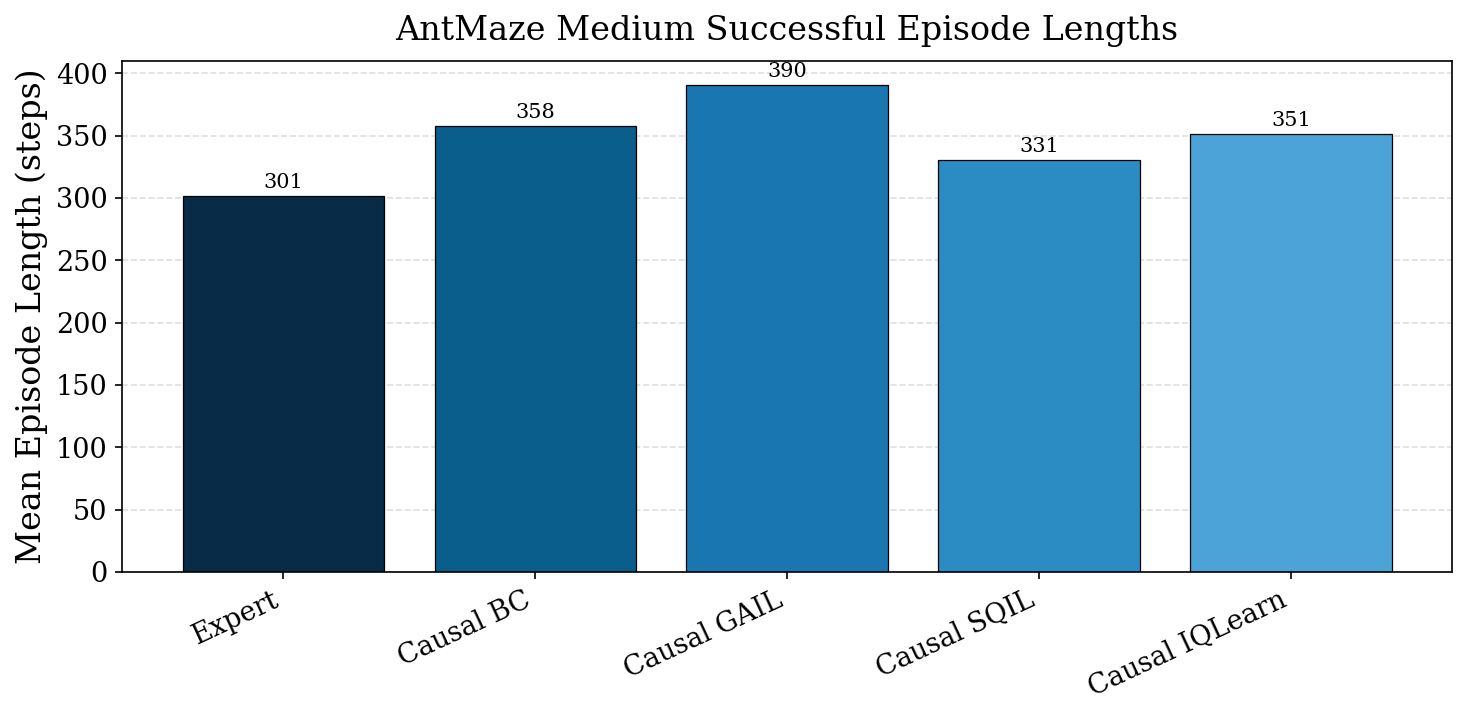

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(x_succ, succ_means, color=succ_colors, edgecolor='black', linewidth=0.6)
ax.set_xticks(x_succ)
ax.set_xticklabels(succ_algos, rotation=25, ha='right')
ax.set_ylabel('Mean Episode Length (steps)')
ax.set_title('AntMaze Medium Successful Episode Lengths', pad=10)
for bar, v in zip(bars, succ_means):
    ax.text(bar.get_x() + bar.get_width()/2, v + 3, f'{v:.0f}',
            ha='center', va='bottom', fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antmed_episode_lengths.pdf', dpi=300, bbox_inches='tight')
plt.show()

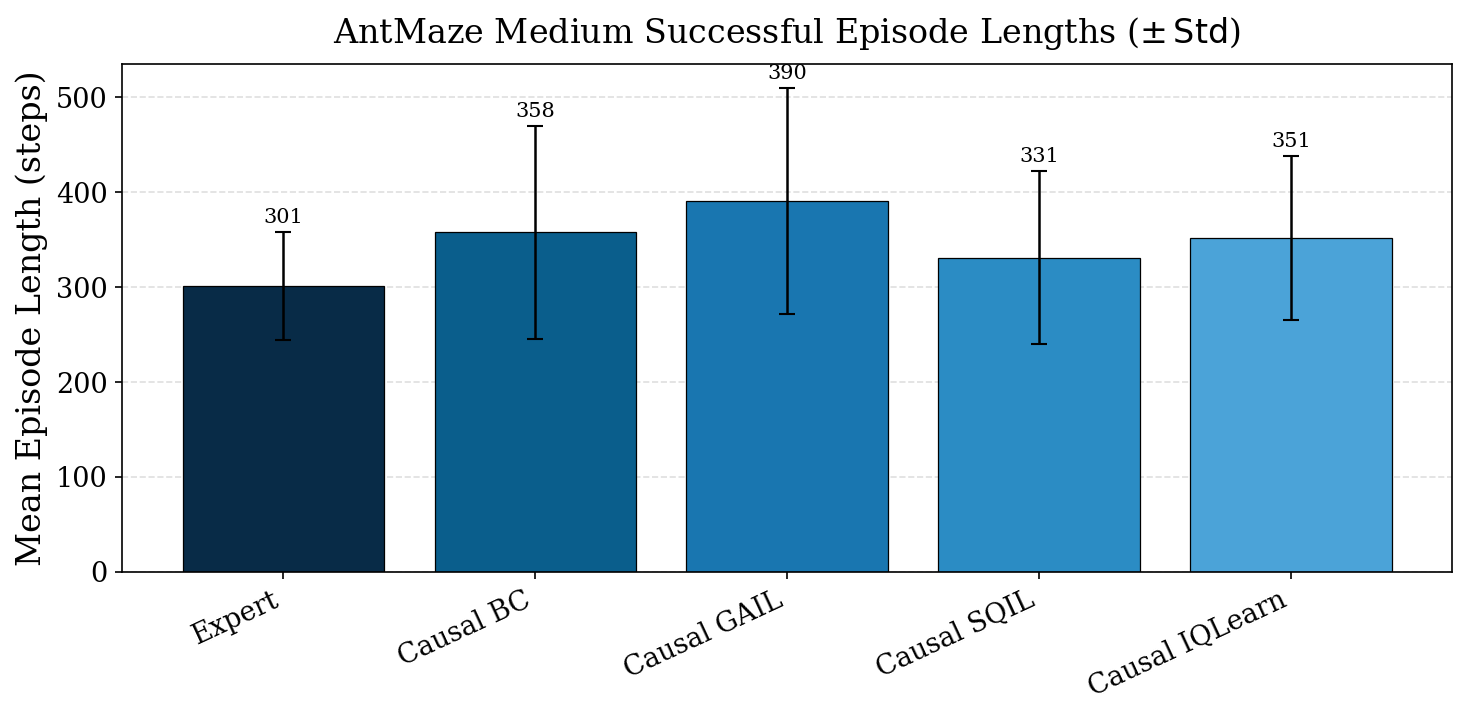

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(x_succ, succ_means, yerr=succ_stds, capsize=4,
              color=succ_colors, edgecolor='black', linewidth=0.6,
              error_kw={'linewidth': 1.2, 'capthick': 1.0})
ax.set_xticks(x_succ)
ax.set_xticklabels(succ_algos, rotation=25, ha='right')
ax.set_ylabel('Mean Episode Length (steps)')
ax.set_title('AntMaze Medium Successful Episode Lengths ($\\pm\\,\\mathrm{Std}$)', pad=10)
for bar, m, s in zip(bars, succ_means, succ_stds):
    ax.text(bar.get_x() + bar.get_width()/2, m + s + 5, f'{m:.0f}',
            ha='center', va='bottom', fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antmed_episode_lengths_with_std.pdf', dpi=300, bbox_inches='tight')
plt.show()